# Melhorias na modelagem para predição de sucesso em campanha de telemarketing

_Tarefa: Classificar se um cliente irá (ou não) realizar um depósito, levando em conta informações de campanhas de marketing via telefone._

<br/>

**Objetivo:** Aplicar técnicas que visem melhorar as métricas de performance sobre o dataset de `teste`.

**1ª versão da modelagem:** [Modelagem com auto ML e LLM para predição de sucesso em campanha de telemarketing](https://github.com/msc2020/labs_ml_genai/blob/main/pred_telemarketing_success/pred_telemarketing_product_acquisition_success.ipynb)

**Dataset:** [Bank Marketing (UCI)](https://archive.ics.uci.edu/dataset/222/bank+marketing)

<br/>

**Overview**

- Construção de um modelo baseline utilizando AutoML.

- Feature engineering para criação de novos atributos.

- Uso de PCA para gerar features.

- Comparação entre as métricas de performance do modelo baseline e dos modelos candidatos.

- Explicação dos resultados de performance com ajuda de um LLM.

- Construção de um modelo baseline utilizando AutoML.

- Feature engineering para criação de novos atributos.

- Uso de PCA para gerar features.

- Comparação entre as métricas de performance do modelo baseline e dos modelos candidatos.

- Explicação dos resultados de performance com ajuda de um LLM.

## Setups iniciais

### Define constantes

In [ ]:
REDUCE_DATASETS = False
PERC_DATASET = 0.01

TEST_SIZE = 0.2
MODEL_TIME_BUDGET = 180
MODEL_METRIC = 'f1' # minimizar FN e FP - não perder clientes (depósitos) e não telefonar em excesso (custos operacionais)


PATH_DATASET_BANK_FULL = 'datasets/bank-full.csv'
PATH_INFOS_BANK_FULL = 'datasets/bank-names.txt'

REPORT_FILE_PATH = 'reports/report_eda_v1.html'
BASELINE_MODEL_PATH = 'trained_models/opt_baseline_pipeline_v1.pkl'
CANDIDATE_FE_MODEL_PATH = 'trained_models/opt_cadidate_pipeline_fe_v1.pkl'
CANDIDATE_PCA_MODEL_PATH = 'trained_models/opt_cadidate_pipeline_pca_v1.pkl'

CREATE_BASELINE_MODEL = True
CREATE_FE_MODEL = True
CREATE_PCA_MODEL = True

### Carrega bibliotecas

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pickle
import time
import json
from typing import List, Dict
from IPython.display import Markdown, display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rich import print

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

from flaml import AutoML

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq

%matplotlib inline
pd.set_option('display.max_columns', None)
np.random.seed(42)

## Prepara dataset

In [3]:
df_bank_full = pd.read_csv(PATH_DATASET_BANK_FULL, sep=';')

if REDUCE_DATASETS:
    df_bank_full = df_bank_full.sample(
        n=round(PERC_DATASET*df_bank_full.shape[0]),
        random_state=42
    )

print('Full dataset:')
print(df_bank_full.shape)
display(df_bank_full.head())

Full dataset:

(45211, 17)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Divide dataset em treino e teste

In [ ]:
cols_to_remove = ['y']

cols_features = [col for col in df_bank_full.columns if col not in cols_to_remove]

df_train, df_test = train_test_split(
    df_bank_full, test_size=TEST_SIZE, stratify=df_bank_full['y'], random_state=42
)

x_test = df_test.drop(columns='y')
y_test = df_test['y']

df_train = df_train[
    (df_train['campaign'] <= df_train['campaign'].quantile(0.99))
]

x_train = df_train.drop(columns=cols_to_remove)
y_train = df_train['y']

print(f'x_train.shape: {x_train.shape}')
print(f'x_test.shape: {x_test.shape}')
print(f'Features: {cols_features}')
df_train.describe()

x_train.shape: (35806, 16)

x_test.shape: (9043, 16)

Features: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 
'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

,age,balance,day,duration,campaign,pdays,previous
count,35806.000000,35806.000000,35806.000000,35806.000000,35806.000000,35806.00000,35806.000000
mean,40.903089,1367.119114,15.745043,260.044406,2.555549,40.57334,0.587611
std,10.634203,3065.348439,8.304600,259.276310,2.217694,100.58172,2.420198
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.00000,0.000000
25%,33.000000,75.000000,8.000000,104.000000,1.000000,-1.00000,0.000000
50%,39.000000,454.000000,16.000000,181.500000,2.000000,-1.00000,0.000000
75%,48.000000,1435.000000,21.000000,319.000000,3.000000,-1.00000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,16.000000,871.00000,275.000000


## Utils

### training_model()

In [5]:
def training_model(
        x_train: pd.DataFrame,
        y_train: pd.Series,
        model_path: str = BASELINE_MODEL_PATH,
        save_model: bool = True
) -> pickle:
    t0 = time.time()
    cat_cols = x_train.select_dtypes(include='object').columns
    num_cols = x_train.select_dtypes(include='number').columns

    onehot_encoder = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=True
    )
    automl = AutoML()
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', onehot_encoder, cat_cols),
            ('num', 'passthrough', num_cols),
        ]
    )
    pipeline = Pipeline(
        steps=[
            ('preprocessing', preprocessor),
            ('model', automl)
        ]
    )
    if type(y_train.iloc[0]) == str:
        _y_train = y_train.map({'no': 0, 'yes':1})
    else:
        _y_train = y_train.copy()

    # Treina modelo com FLAML AutoML
    pipeline.fit(
        X=x_train,
        y=_y_train,
        model__task='classification',
        model__metric=MODEL_METRIC,
        model__time_budget=MODEL_TIME_BUDGET,
        model__verbose=0
    )

    print('\n=== Modelo ótimo ===\n')
    print(f'Name: {pipeline.named_steps['model'].best_estimator}')
    print(f'Loss: {pipeline.named_steps['model'].best_loss: .4f}')
    print(f'Tempo gasto: {(time.time() - t0)/60: .2f} min')

    # exporta modelo
    with open(model_path, 'wb') as f:
        pickle.dump(pipeline, f)   
    
    return pipeline

### compute_metrics()

In [ ]:
def compute_metrics(
        x: pd.DataFrame,
        y: pd.Series,
        pipeline: pickle,
        threshold: float = 0.5,
        suffix: str = None
) -> pd.DataFrame:
    y_prob = pipeline.predict_proba(x)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    y_pred = np.where(y_pred == 1, 'yes', 'no').tolist()
    
    if type(y.iloc[0]) == str:
        y_num = [1 if i == 'yes' else 0 for i in y]
        y_pred_num = [1 if i == 'yes' else 0 for i in y_pred]
    else:
        y_num = y.copy()
        y_pred_num = y_pred.copy()
    metrics = {
        f'f1_{suffix}': f1_score(y_num, y_pred_num),
        f'accuracy_{suffix}': accuracy_score(y_num, y_pred_num),
        f'precision_{suffix}': precision_score(y_num, y_pred_num),
        f'recall_{suffix}': recall_score(y_num, y_pred_num),
        f'roc_auc_{suffix}': roc_auc_score(y_num, y_prob),
    }

    return pd.DataFrame(metrics, index=['metrics'])

### plot_train_test_metrics()

In [7]:

def plot_train_test_metrics(
    metrics_train: pd.DataFrame,
    metrics_test: pd.DataFrame
):
    metrics = [col.replace('_train','').replace('_test','') for col in metrics_train.columns]

    train_values = metrics_train.iloc[0].values
    test_values  = metrics_test.iloc[0].values

    x = np.arange(len(metrics))
    width = 0.3

    fig, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, train_values, width, label='Train', color='darkblue')
    rects2 = ax.bar(x + width/2, test_values, width, label='Test', color='darkorange')

    ax.set_ylabel('Score')
    ax.set_xlabel('Métrica')
    ax.set_title('Métricas Treino vs Teste')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

### plot_compare_train_test_metrics()

In [ ]:
def plot_compare_train_test_metrics(
    metrics_train: pd.DataFrame,
    metrics_test: pd.DataFrame,
    candidate_train_metrics: pd.DataFrame,
    candidate_test_metrics: pd.DataFrame
):
    metrics = [col.replace('_train','').replace('_test','') for col in metrics_train.columns]

    train_values = metrics_train.iloc[0].values
    test_values  = metrics_test.iloc[0].values

    candidate_train_values = candidate_train_metrics.iloc[0].values
    candidate_test_values  = candidate_test_metrics.iloc[0].values

    x = np.arange(len(metrics))
    width = 0.15

    fig, ax = plt.subplots(figsize=(14, 5))

    rects1 = ax.bar(x - width * 1.5, train_values, width, label='Train Baseline', color='darkblue')
    rects2 = ax.bar(x - width * 0.5, test_values, width, label='Test Baseline', color='darkorange')
    rects3 = ax.bar(x + width * 0.5, candidate_train_values, width, label='Train Candidate', color='darkgreen')
    rects4 = ax.bar(x + width * 1.5, candidate_test_values, width, label='Test Candidate', color='darkviolet')

    ax.set_ylabel('Score')
    ax.set_xlabel('Métrica')
    ax.set_title('Métricas Treino vs Teste')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

    for rect in rects1 + rects2 + rects3 + rects4:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

### plot_tradeoff_precision_recall()

In [ ]:
def plot_tradeoff_precision_recall(
    candidate_models: Dict[str, Pipeline],
    x_train: pd.DataFrame,
    x_train_candidate: pd.DataFrame
):
    threshold_default = 0.5
    models_dev = candidate_models.keys()

    plt.figure(figsize=(15, 5), dpi=90)
    for model_name in models_dev:    
        if model_name == 'Baseline':
            y_train_pred = pd.DataFrame(candidate_models[model_name].predict_proba(x_train))    
            precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_pred[1], pos_label='yes')
            plt.plot(thresholds, precisions[:-1], '--', label=f'Precision - {model_name}') 
            plt.plot(thresholds, recalls[:-1], 'g-', label=f'Recall - {model_name}')
        else:
            y_train_pred = pd.DataFrame(candidate_models[model_name].predict_proba(x_train_candidate))    
            precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_pred[1], pos_label='yes')
            plt.plot(thresholds, precisions[:-1], 'b--', label=f'Precision - {model_name}') 
            plt.plot(thresholds, recalls[:-1], 'r-', label=f'Recall - {model_name}')
            plt.plot([0.5, 0.5], [0, max(precisions)], 'k-', label=f'Threshold = {threshold_default}', linewidth=3)
        plt.xticks(np.arange(0, 1.05, 0.05))
        plt.yticks(np.arange(0, 1.05, 0.05))
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.xlabel('Threshold')
        plt.title('Precision x Recall')
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(models_dev))

## Modelo baseline

### Predições com modelo baseline

In [10]:
if CREATE_BASELINE_MODEL:
    baseline_pipeline = training_model(x_train=x_train, y_train=y_train)
else:
    with open(BASELINE_MODEL_PATH, 'rb') as f:
        baseline_pipeline = pickle.load(f)
        print(f'baseline_pipeline: {baseline_pipeline}')

=== Modelo ótimo ===

Name: xgb_limitdepth

Loss:  0.4049

Tempo gasto:  3.03 min

###  Métricas baseline

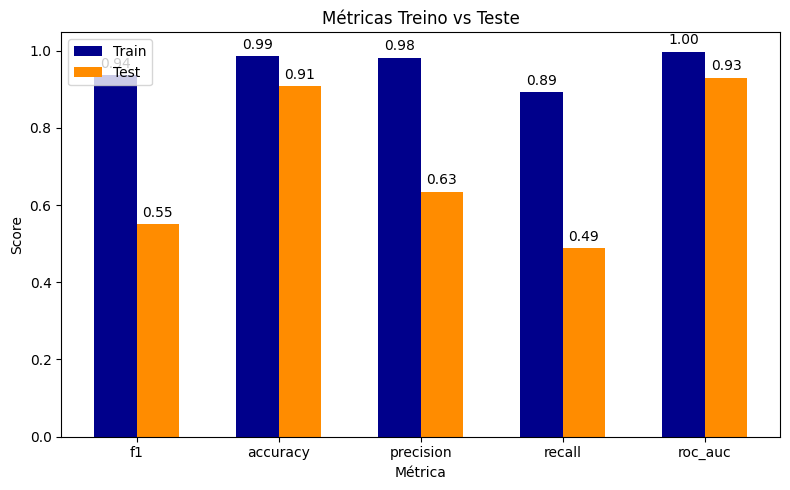

In [11]:
threshold_baseline = 0.5

train_metrics = compute_metrics(
    x=x_train, y=y_train, pipeline=baseline_pipeline, suffix='train', threshold=threshold_baseline
)

test_metrics = compute_metrics(
    x=x_test, y=y_test, pipeline=baseline_pipeline, suffix='test', threshold=threshold_baseline
)

all_metrics = pd.concat([train_metrics, test_metrics], axis=1).T

plot_train_test_metrics(train_metrics, test_metrics)

### Explicação da performance com LLM 

In [ ]:
def explain_results(all_metrics: pd.DataFrame):
    template = '''
    You are an expert in evaluating machine learning performance.

    Given the input in JSON format containing the calculated performance 
    metrics, explain in clear, simple, and technical language the performance of our model.

    Provide the response in bullet points. Be concise and present a conclusion.

    Input (JSON):
    {all_model_metrics}
    '''

    prompt_template = PromptTemplate.from_template(
        template=template
    )

    llm_model = ChatGroq(
        temperature=0,
        max_tokens=300,
    )

    system_prompt = 'How did the model perform on the training and test datasets?'
    user_prompt = prompt_template.format(all_model_metrics=all_metrics.to_json())
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = llm_model.invoke(messages)
    display(Markdown(f'🤖: {response.content}'))

In [13]:
explain_results(all_metrics)

🤖: * **Training Performance:**
  * High accuracy (98.55%) and F1 score (93.55%) indicate excellent performance on the training dataset.
  * Precision (98.20%) and recall (89.31%) are also high, suggesting the model is effective in identifying true positives.
  * ROC-AUC score (99.74%) is close to 1, indicating the model is highly effective in distinguishing between classes.
* **Testing Performance:**
  * Lower accuracy (90.72%) and F1 score (55.16%) on the test dataset indicate a significant drop in performance.
  * Precision (63.47%) and recall (48.77%) are lower than in the training dataset, suggesting the model may be overfitting.
  * ROC-AUC score (93.02%) is still relatively high, but lower than in the training dataset.
* **Conclusion:** The model performs exceptionally well on the training dataset but experiences a significant drop in performance on the test dataset, indicating potential overfitting. Further tuning and regularization techniques may be necessary to improve the model's generalization capabilities.

## Modelos candidatos

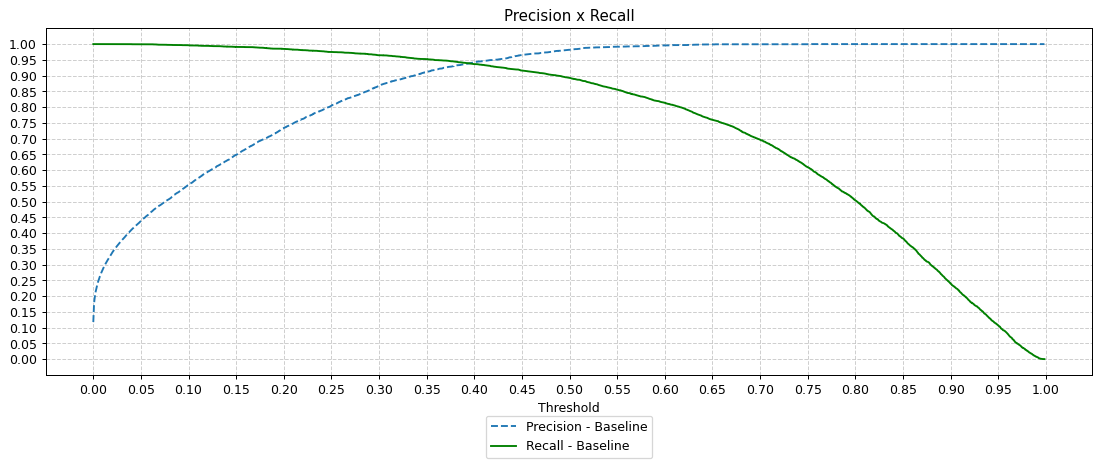

In [14]:
plot_tradeoff_precision_recall(
    candidate_models={'Baseline': baseline_pipeline},
    x_train=x_train,
    x_train_candidate=x_train
)

### 1. Altera threshold

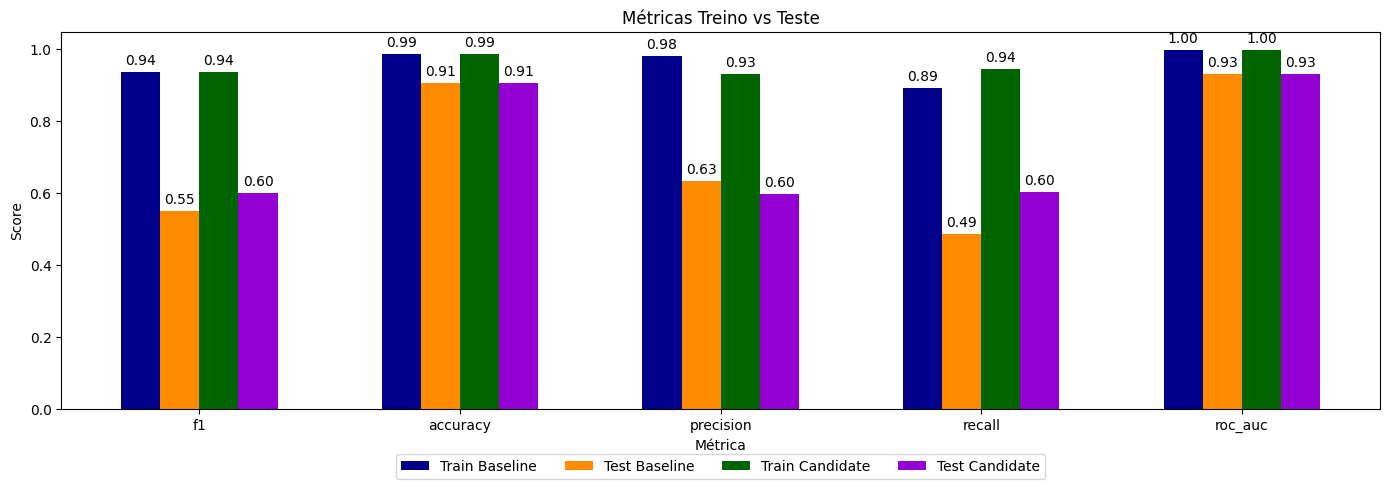

In [15]:
threshold_tests = 0.38
train_metrics_candidate1 = compute_metrics(
    x=x_train, y=y_train, pipeline=baseline_pipeline, suffix='train', threshold=threshold_tests
)

test_metrics_candidate1 = compute_metrics(
    x=x_test, y=y_test, pipeline=baseline_pipeline, suffix='test', threshold=threshold_tests
)

all_metrics_candidate_treshold = pd.concat([train_metrics_candidate1, test_metrics_candidate1], axis=1).T

plot_compare_train_test_metrics(
    metrics_train=train_metrics,
    metrics_test=test_metrics,
    candidate_train_metrics=train_metrics_candidate1,
    candidate_test_metrics=test_metrics_candidate1
)

In [16]:
explain_results(all_metrics_candidate_treshold)

🤖: * **Training Performance:**
  * High accuracy (98.52%) and F1 score (93.78%) indicate excellent performance on the training dataset.
  * Precision (93.13%) and recall (94.43%) are also high, suggesting a good balance between true positives and false positives.
  * ROC-AUC score (99.74%) is close to 1, indicating excellent separation between classes.
* **Testing Performance:**
  * Lower accuracy (90.62%) and F1 score (60.05%) on the test dataset indicate a significant drop in performance compared to the training dataset.
  * Precision (59.79%) and recall (60.30%) are relatively low, suggesting a higher number of false positives and false negatives.
  * ROC-AUC score (93.02%) is still relatively high, but lower than the training dataset.
* **Conclusion:** The model performs exceptionally well on the training dataset but experiences a significant drop in performance on the test dataset, indicating potential **overfitting**. This suggests that the model may be too complex or has memorized the training data, and may not generalize well to new, unseen data.

### 2. Feature engineering

#### Adiciona features

In [ ]:
def apply_feature_engineering(x: pd.DataFrame) -> pd.DataFrame:
    ### temporal features ###
    month_map = {
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
        'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
        'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
    }
    x['month_num'] = x['month'].map(month_map)
    x['quarter'] = (x['month_num']) // 3 + 1
    x['day_group'] = pd.cut(
        x['day'],
        bins=[0, 10, 20, 31],
        labels=['start', 'middle', 'end']
    )

    ### financial features ###
    x['has_balance'] = (x['balance'] > 0).astype(int)
    x['log_balance'] =  np.sign(x['balance']) * np.log1p(np.abs(x['balance']))
    x['has_debt'] = ((x['loan'] == 'yes') | (x['housing'] == 'yes')).astype(int)
    x['financial_status'] = (
        (x['balance'] > 0).astype(int)
        - (x['loan'] == 'yes').astype(int)
    )
    x['balance_bucket'] = pd.cut(
        x['balance'],
        bins=[-np.inf, 0, 450, 1400, np.inf],
        labels=['debt', 'low', 'medium', 'high']
    )

    ### contact features ###
    x['was_contacted_before'] = (x['previous'] > 0).astype(int)
    x['pdays_contacted'] = x['pdays'].replace(-1, 999)
    x['contact_intensity'] = x['campaign'] + x['previous']


    ### others ###
    x['balance_per_age'] = x['balance'] / x['age']
    x['campaign_ratio'] = x['campaign'] / (x['previous'] + 1)
    x['education_job'] = x['education'].astype(str) + "_" + x['job'].astype(str)
    x['job_freq'] = x['job'].map(x['job'].value_counts())
    x['prev_success'] = (x['poutcome'] == 'success').astype(int)

    display(x.head())

    return x

In [18]:
x_train_fe = apply_feature_engineering(x_train)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,month_num,quarter,day_group,has_balance,log_balance,has_debt,financial_status,balance_bucket,was_contacted_before,pdays_contacted,contact_intensity,balance_per_age,campaign_ratio,education_job,job_freq,prev_success
24001,36,technician,divorced,secondary,no,861,no,no,telephone,29,aug,140,2,-1,0,unknown,8,3,end,1,6.759255,0,1,medium,0,999,2,23.916667,2.0,secondary_technician,5995,0
43409,24,student,single,secondary,no,4126,no,no,cellular,5,apr,907,4,185,7,failure,4,2,start,1,8.325306,0,1,high,1,185,11,171.916667,0.5,secondary_student,754,0
20669,44,technician,single,secondary,no,244,yes,no,cellular,12,aug,1735,4,-1,0,unknown,8,3,middle,1,5.501258,1,1,low,0,999,4,5.545455,4.0,secondary_technician,5995,0
18810,48,unemployed,married,secondary,no,0,no,no,telephone,31,jul,35,11,-1,0,unknown,7,3,end,0,0.000000,0,0,debt,0,999,11,0.000000,11.0,secondary_unemployed,1019,0
23130,38,technician,married,secondary,no,257,no,no,cellular,26,aug,57,10,-1,0,unknown,8,3,end,1,5.552960,0,1,low,0,999,10,6.763158,10.0,secondary_technician,5995,0


In [19]:
x_test_fe = apply_feature_engineering(x_test) 

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,month_num,quarter,day_group,has_balance,log_balance,has_debt,financial_status,balance_bucket,was_contacted_before,pdays_contacted,contact_intensity,balance_per_age,campaign_ratio,education_job,job_freq,prev_success
1392,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,347,2,-1,0,unknown,5,2,start,1,6.463029,1,0,medium,0,999,2,16.000000,2.0,primary_blue-collar,1902,0
7518,44,technician,married,secondary,no,378,yes,no,unknown,30,may,203,2,-1,0,unknown,5,2,end,1,5.937536,1,1,low,0,999,2,8.590909,2.0,secondary_technician,1529,0
12007,31,services,married,secondary,no,356,yes,no,unknown,20,jun,228,5,-1,0,unknown,6,3,middle,1,5.877736,1,1,low,0,999,5,11.483871,5.0,secondary_services,806,0
5536,36,blue-collar,married,primary,no,655,yes,no,unknown,23,may,153,4,-1,0,unknown,5,2,end,1,6.486161,1,1,medium,0,999,4,18.194444,4.0,primary_blue-collar,1902,0
29816,34,services,single,secondary,no,1921,yes,no,cellular,4,feb,61,1,-1,0,unknown,2,1,start,1,7.561122,1,1,high,0,999,1,56.500000,1.0,secondary_services,806,0


#### Treina modelo candidato com novas features

In [20]:
if CREATE_FE_MODEL:
    candidate_fe_model = training_model(
        x_train=x_train_fe,
        y_train=y_train,
        model_path=CANDIDATE_FE_MODEL_PATH,
    )
else:
    with open(CANDIDATE_FE_MODEL_PATH, 'rb') as f:
        candidate_fe_model = pickle.load(f)
        print(f'candidate_fe_model: {candidate_fe_model}')

=== Modelo ótimo ===

Name: xgb_limitdepth

Loss:  0.3902

Tempo gasto:  3.10 min

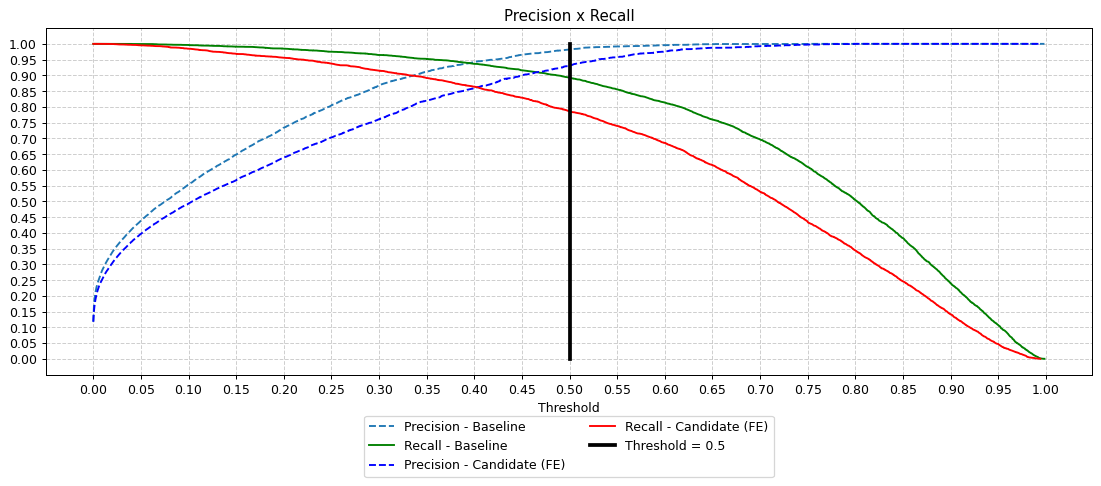

In [21]:
plot_tradeoff_precision_recall(
    candidate_models={'Baseline': baseline_pipeline, 'Candidate (FE)': candidate_fe_model},
    x_train=x_train,
    x_train_candidate=x_train_fe
)

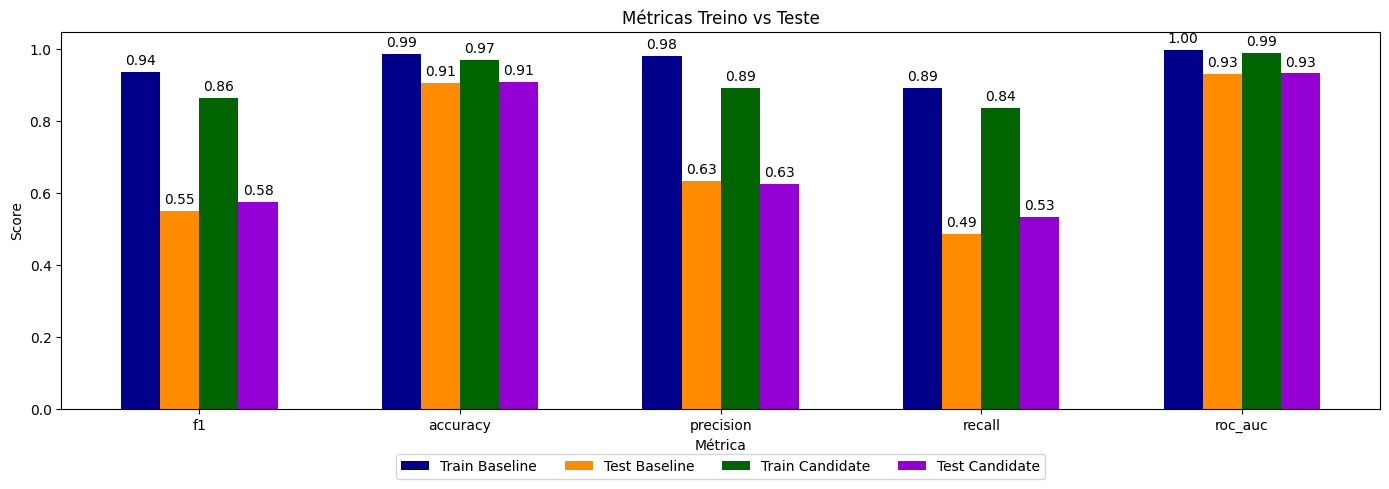

In [22]:
threshold_fe = 0.44

x_test_fe.reset_index(drop=True, inplace=True)

train_metrics_fe = compute_metrics(
    x=x_train_fe,
    y=y_train,
    pipeline=candidate_fe_model,
    threshold=threshold_fe,
    suffix='train_fe'
)
test_metrics_fe = compute_metrics(
    x=x_test_fe,
    y=y_test,
    pipeline=candidate_fe_model,
    threshold=threshold_fe,
    suffix='test_fe'
)

all_metrics_fe = pd.concat([train_metrics_fe, test_metrics_fe], axis=1).T

plot_compare_train_test_metrics(
    metrics_train=train_metrics,
    metrics_test=test_metrics,
    candidate_train_metrics=train_metrics_fe,
    candidate_test_metrics=test_metrics_fe,
)

In [23]:
explain_results(all_metrics_fe)

🤖: * **Training Performance:**
  * High accuracy (96.87%) and F1 score (86.31%) indicate excellent performance on the training dataset.
  * Precision (89.23%) and recall (83.58%) are also high, showing a good balance between true positives and false positives.
  * ROC-AUC score (98.90%) is close to 1, indicating excellent separation between classes.
* **Testing Performance:**
  * Lower accuracy (90.82%) and F1 score (57.66%) compared to training, indicating some overfitting.
  * Precision (62.64%) and recall (53.40%) are lower than in training, suggesting a higher number of false negatives and false positives.
  * ROC-AUC score (93.23%) is still high, but lower than in training, indicating some loss of separation between classes.
* **Conclusion:** The model performs well on the training dataset but shows signs of overfitting, with a significant drop in performance on the test dataset. This suggests that the model may be too complex or has memorized the training data, and techniques such as regularization or data augmentation may be necessary to improve generalization to new data.

### 3. Aplica PCA

In [24]:
EXPLAINED_VARIANCE_THRESHOLD = 0.90

In [ ]:
def apply_pca(
    x: pd.DataFrame,
    standardize=True,
    explained_variance_threshold: float = EXPLAINED_VARIANCE_THRESHOLD,
    is_training: bool = False
):
    scaler_model_path = 'trained_models/scaler_pca.pkl'
    pca_model_path = 'trained_models/pca_model.pkl'
    features = x.columns

    if x.isnull().values.any():
        raise ValueError('X contains missing values (NaNs). Please handle them before applying PCA.')
    
    if is_training:
        if standardize:
            scaler = StandardScaler()
            x = scaler.fit_transform(x)
        
        with open(scaler_model_path, 'wb') as f:
            pickle.dump(scaler, f)

        pca = PCA(n_components=x.shape[1])
        x_pca = pca.fit_transform(x)

        explained_variance_ratio = pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance_ratio)
        n_components = np.argmax(cumulative_variance >= explained_variance_threshold) + 1

        pca = PCA(n_components=n_components)
        x_pca = pca.fit_transform(x)

        with open(pca_model_path, 'wb') as f:
            pickle.dump(pca, f)
    else:
        with open(scaler_model_path, 'rb') as f:
            scaler = pickle.load(f)
            print(f'scaler: {scaler}')
       
        with open(pca_model_path, 'rb') as f:
            pca = pickle.load(f)
            print(f'pca: {pca}')
        x_pca = pca.transform(x)
        

    component_names = [f'pc_{i+1}' for i in range(x_pca.shape[1])]
    df_pca = pd.DataFrame(x_pca, columns=component_names)
    
    loadings_df = pd.DataFrame(
        pca.components_.T,
        columns=component_names,
        index=features
    )
    
    return pca, df_pca, loadings_df, pca.explained_variance_ratio_

In [ ]:
pca, x_train_pca, loadings, _ = apply_pca(
    x=x_train.select_dtypes('number'),
    is_training=CREATE_PCA_MODEL
)

In [27]:
pd.DataFrame(loadings.sort_values(by=['pc_1']))

,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11
pdays_contacted,-0.468900,0.126112,-0.035295,-0.090395,0.007837,0.003400,0.030006,-0.104046,-0.081914,-0.001926,-0.144466
campaign_ratio,-0.223271,0.059722,0.515477,-0.151562,0.001673,-0.031671,0.041411,0.046321,0.180112,-0.039509,0.192850
campaign,-0.103124,0.021025,0.572564,-0.150629,0.008620,-0.028117,0.033736,0.033660,0.171428,-0.037539,0.206102
day,-0.073532,0.027548,0.141580,0.050947,0.017628,0.088209,-0.149988,0.819621,-0.479452,0.184387,-0.056799
quarter,-0.064065,0.153514,0.140306,0.615545,-0.095395,0.209598,0.018323,-0.096744,-0.021924,-0.059545,0.050248
month_num,-0.061707,0.146933,0.143482,0.610536,-0.083104,0.245878,0.011303,-0.090648,-0.035860,-0.049803,0.063626
job_freq,-0.009872,-0.036859,0.011998,-0.077368,0.149400,0.558558,0.050669,0.015313,0.389189,0.646578,-0.280126
has_debt,-0.004975,-0.174695,-0.052781,-0.160627,0.250566,0.438218,0.002102,-0.157878,-0.253280,0.006989,0.578823
age,0.003680,0.067197,0.044893,0.152730,-0.130137,-0.518586,-0.077078,-0.194644,-0.120871,0.720322,0.273802
duration,0.011109,0.018406,-0.064080,0.005557,0.010194,-0.038317,0.964647,0.090464,-0.163869,0.071600,0.073865


In [28]:
x_train_pca.shape

(35806, 11)

In [29]:
x_train.shape

(35806, 32)

In [ ]:
def add_pca_features(x: pd.DataFrame, loadings: pd.DataFrame) -> pd.DataFrame:
    x_pca_features = x[loadings.index]

    pca_features = x_pca_features.values @ loadings.values

    pca_features_df = pd.DataFrame(
        pca_features,
        columns=[f'pc_{i+1}' for i in range(loadings.shape[1])],
        index=x_pca_features.index
    )

    x_augmented = pd.concat([x, pca_features_df], axis=1)

    return x_augmented

In [31]:
x_train_augmented = add_pca_features(x=x_train, loadings=loadings)

#### Treina modelo candidato

In [32]:
if CREATE_PCA_MODEL:
    candidate_pca_model = training_model(
        x_train=x_train_augmented,
         y_train=y_train,
        model_path=CANDIDATE_PCA_MODEL_PATH,
    )
else:
    with open(CANDIDATE_PCA_MODEL_PATH, 'rb') as f:
        candidate_pca_model = pickle.load(f)
        print(f'candidate_pca_model: {candidate_pca_model}')

=== Modelo ótimo ===

Name: xgboost

Loss:  0.3898

Tempo gasto:  3.02 min

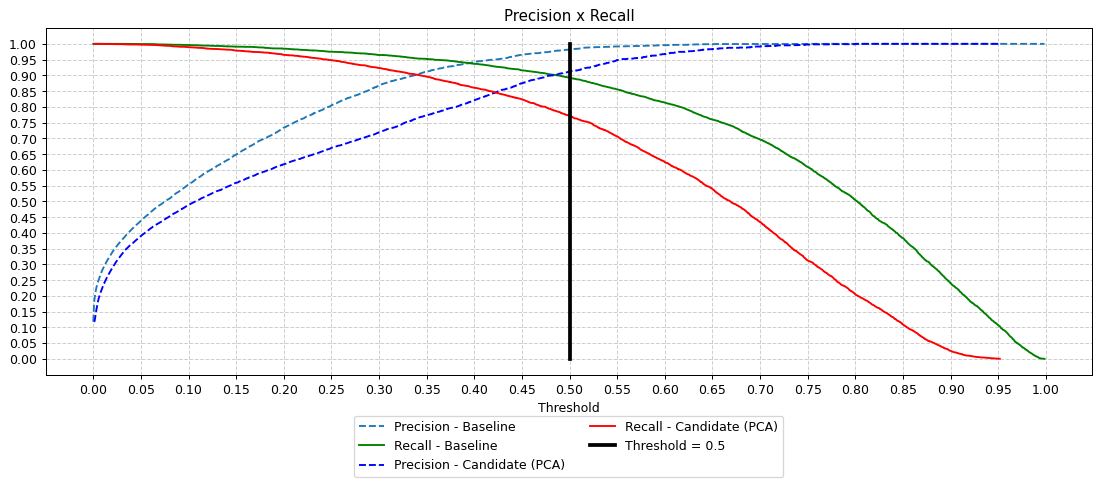

In [33]:
plot_tradeoff_precision_recall(
    candidate_models={'Baseline': baseline_pipeline, 'Candidate (PCA)': candidate_pca_model},
    x_train=x_train,
    x_train_candidate=x_train_augmented
)

scaler: StandardScaler()

pca: PCA(n_components=np.int64(11))

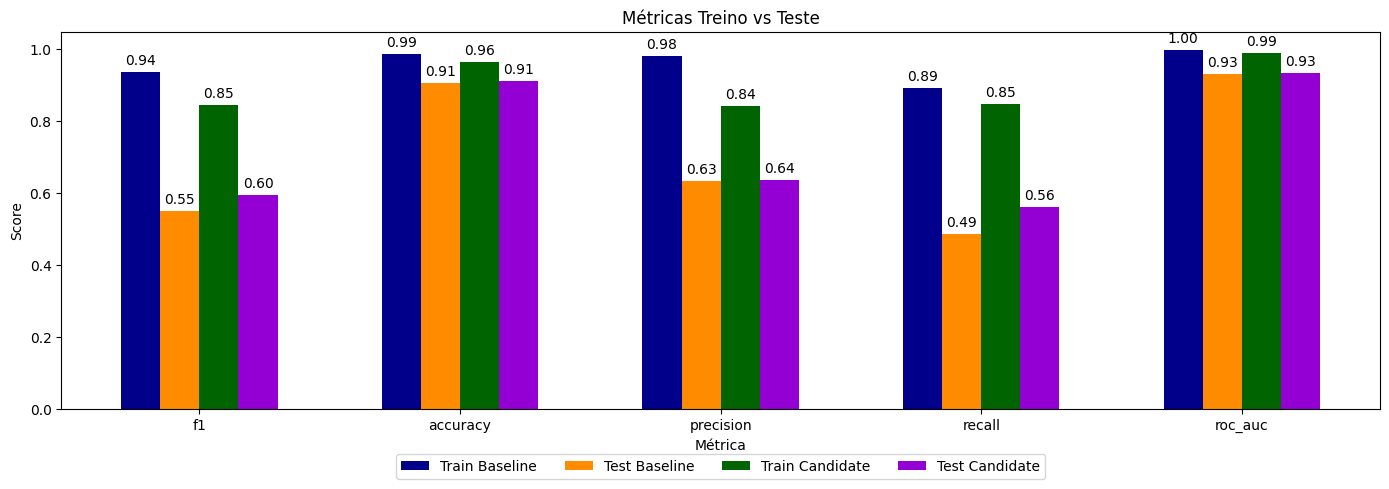

In [34]:
threshold_pca = 0.42
_, x_test_pca, _, _ = apply_pca(
    x=x_test.select_dtypes('number'),
)

x_test_augmented = add_pca_features(x=x_test, loadings=loadings)

train_metrics_pca = compute_metrics(
    x=x_train_augmented,
    y=y_train,
    pipeline=candidate_pca_model,
    threshold=threshold_pca,
    suffix='train_pca'
)
test_metrics_pca = compute_metrics(
    x=x_test_augmented,
    y=y_test,
    pipeline=candidate_pca_model,
    threshold=threshold_pca,
    suffix='test_pca'
)

all_metrics_pca = pd.concat([train_metrics_pca, test_metrics_pca], axis=1).T

plot_compare_train_test_metrics(
    metrics_train=train_metrics,
    metrics_test=test_metrics,
    candidate_train_metrics=train_metrics_pca,
    candidate_test_metrics=test_metrics_pca,
)

In [35]:
explain_results(all_metrics_pca)

🤖: * **Training Performance:**
  * High accuracy: 96.34%
  * High F1 score: 84.54%
  * High precision: 84.31%
  * High recall: 84.77%
  * Excellent ROC-AUC score: 98.82%
* **Testing Performance:**
  * Lower accuracy: 91.12%
  * Lower F1 score: 59.63%
  * Lower precision: 63.69%
  * Lower recall: 56.05%
  * Good ROC-AUC score: 93.35%
* **Conclusion:** The model performs well on the training dataset but shows a significant decrease in performance on the test dataset, indicating potential **overfitting**. The model is able to fit the training data very well but struggles to generalize to new, unseen data. Techniques such as regularization, hyperparameter tuning, or collecting more data may be necessary to improve the model's performance on the test dataset.

## Informações sobre o dataset Bank Marketing (UCI)

In [36]:
with open(PATH_INFOS_BANK_FULL, 'r', encoding='utf-8') as f:
    content = f.read()
print(content)

Citation Request:
  This dataset is public available for research. The details are described in [Moro et al., 2011]. 
  Please include this citation if you plan to use this database:

  [Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An 
Application of the CRISP-DM Methodology. 
  In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 
117-121, Guimarães, Portugal, October, 2011. EUROSIS.

  Available at:  http://hdl.handle.net/1822/14838
                 http://www3.dsi.uminho.pt/pcortez/bib/2011-esm-1.txt

1. Title: Bank Marketing

2. Sources
   Created by: Paulo Cortez (Univ. Minho) and Sérgio Moro (ISCTE-IUL) @ 2012
   
3. Past Usage:

  The full dataset was described and analyzed in:

  S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM 
Methodology. 
  In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 
117-121, Guimarães, 
  Portugal, October, 2011. EUROSIS.

4. Relevant Information:

   The data is related with direct marketing campaigns of a Portuguese banking institution. 
   The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required,
   in order to access if the product (bank term deposit) would be (or not) subscribed. 

   There are two datasets: 
      1) bank-full.csv with all examples, ordered by date (from May 2008 to November 2010).
      2) bank.csv with 10% of the examples (4521), randomly selected from bank-full.csv.
   The smallest dataset is provided to test more computationally demanding machine learning algorithms (e.g. SVM).

   The classification goal is to predict if the client will subscribe a term deposit (variable y).

5. Number of Instances: 45211 for bank-full.csv (4521 for bank.csv)

6. Number of Attributes: 16 + output attribute.

7. Attribute information:

   For more information, read [Moro et al., 2011].

   Input variables:
   # bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: 
"admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or 
widowed)
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   5 - default: has credit in default? (binary: "yes","no")
   6 - balance: average yearly balance, in euros (numeric) 
   7 - housing: has housing loan? (binary: "yes","no")
   8 - loan: has personal loan? (binary: "yes","no")
   # related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
  10 - day: last contact day of the month (numeric)
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last 
contact)
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, 
-1 means client was not previously contacted)
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  Output variable (desired target):
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")

8. Missing Attribute Values: None